    Student ID      Name  Math  English  Science  Attendance (%)
0         S001   Queen K    71       79       83              97
1         S002  Lilian W    75       89       52              76
2         S003    Ryan L    95       52       36              87
3         S004   Brian H    56       97       36             100
4         S005   Oscar T    35       96       43              92
5         S006   Nancy A    44       77       86              81
6         S007    Alex U    58       87       95              86
7         S008    Alex S    48       91       93              79
8         S009   Henry P    54       84       91              62
9         S010   Queen W    50       57       85              79
10        S011   Nancy X    53       96       48              81
11        S012   Queen P    47       91       83              86
12        S013   Nancy W    50       78       86              76
13        S014     Pat B    60       97       90              61
14        S015    Alex B 

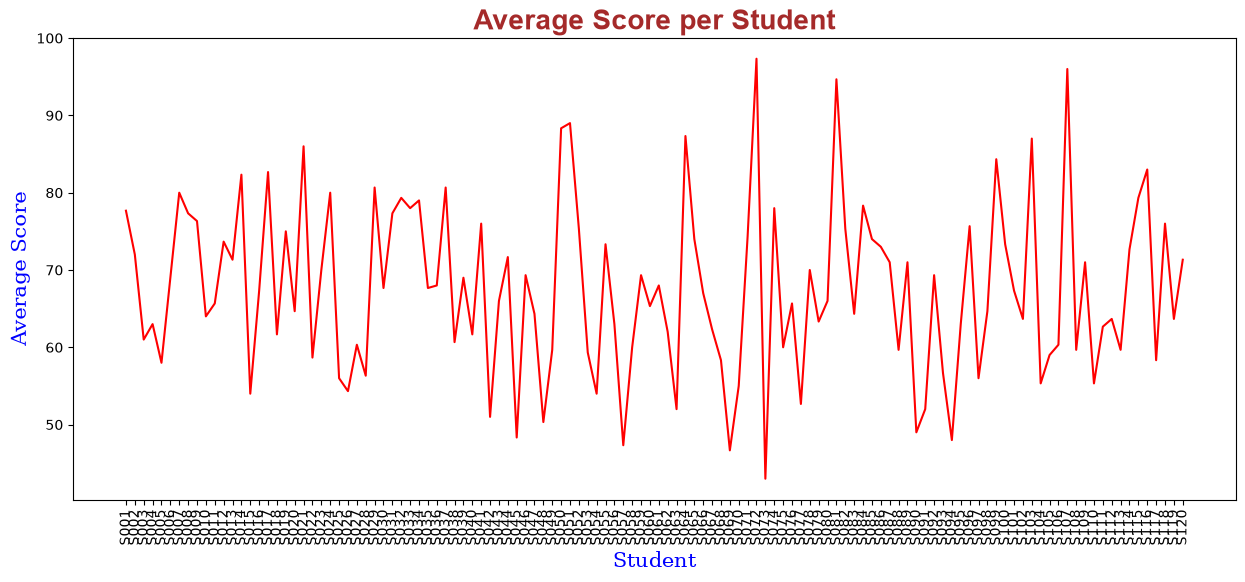

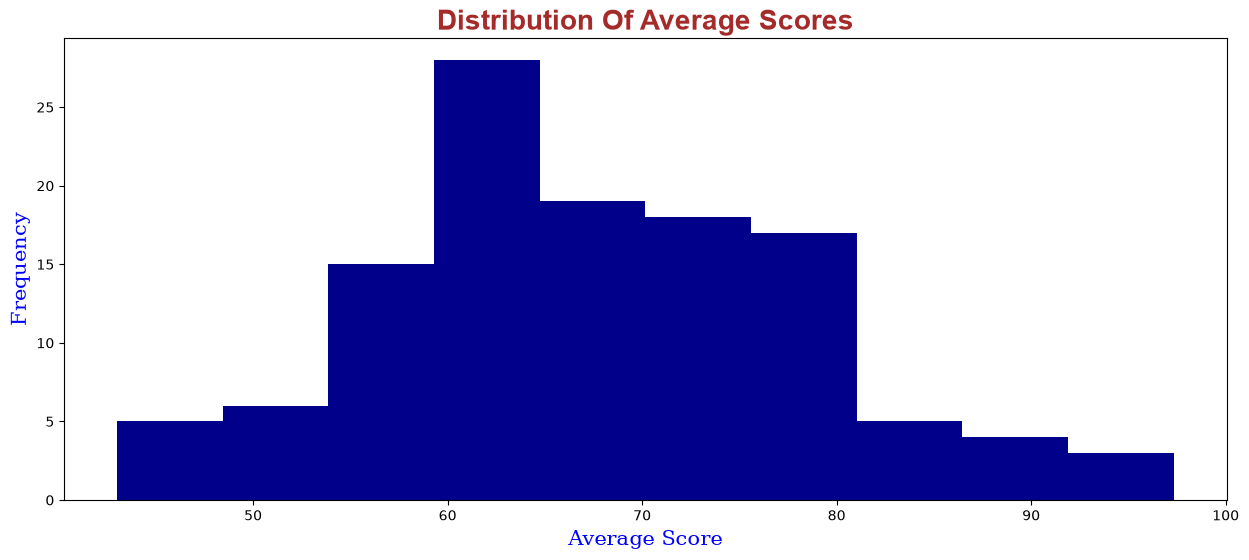

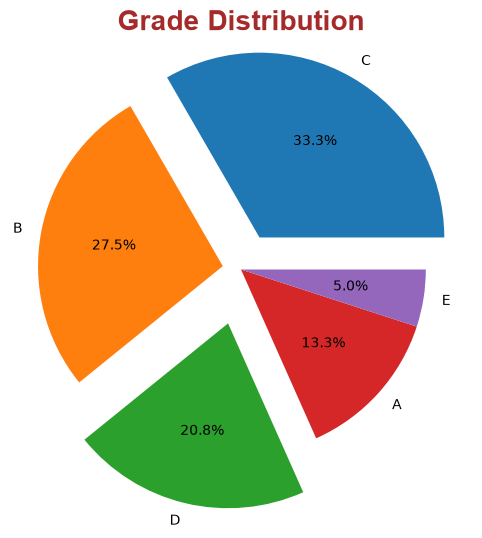

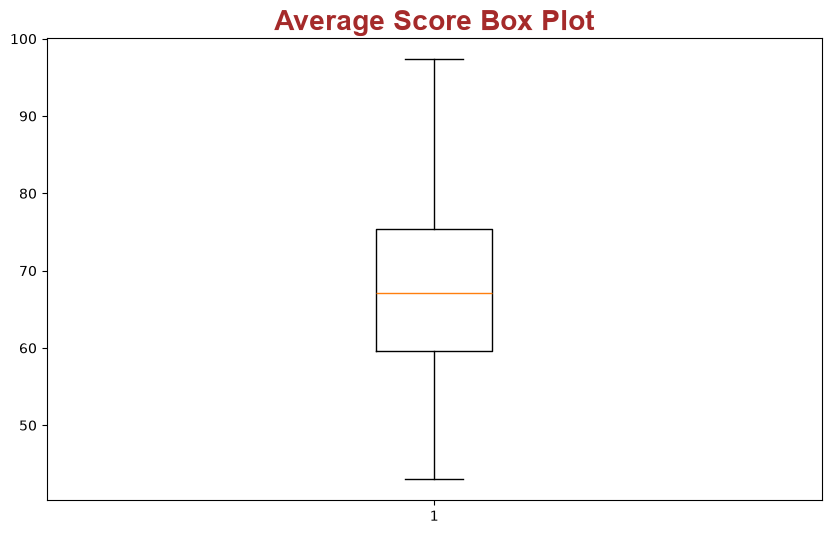

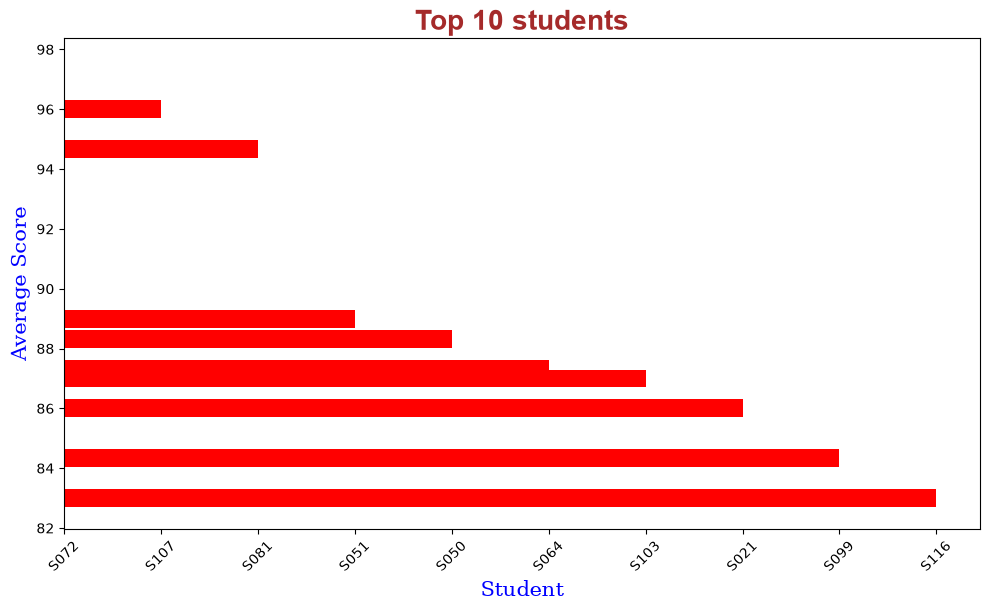

In [99]:
# STUDENT MANAGEMENT SYSTEM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Loading Dataset
df=pd.read_excel(r"C:\Users\user\Downloads\Student_Performance_Dataset_120_Rows.xlsx")
print(df.to_string())

#1. DATA CLEANING
# Checking for missing values
print('=====================================================================================================')
ED=df.isnull().sum()
print(ED)

# Checking for duplicate values
print('=====================================================================================================')
ED1=df.duplicated().sum()
print(ED1)

# Dropping duplicates
print('=====================================================================================================')
ED2=df.drop_duplicates(inplace=True)
print(ED2)

# 2. INSPECTING THE DATASET
print('=====================================================================================================')
# Checking dataset information
ED3=df.info()
print(ED3)

# Checking dataset description
print('=====================================================================================================')
ED4=df.describe()
print(ED4)

# Checking dataset shape
print('=====================================================================================================')
ED5=df.shape
print(ED5)

## 3. FEATURE ENGINEERING
# Adding total marks column
df['Total Marks']=df['Math']+df['English']+df['Science']
df

# Adding Average Score column
df['Average Score']=(df['Total Marks']/3).round(2)
df

# Grading the students
# Create a grade function
def grade(score):
    if score>=80:
        return 'A'
    elif score>=70:
        return 'B'
    elif score>=60:
        return 'C'
    elif score>=50:
        return 'D'
    else:
        return 'E'

# Applying the function to the dataset
df['Grade']=df['Average Score'].apply(grade)
df
print('=====================================================================================================')
print(df.to_string())

# Finding the status of each student
# Create a status function
def status(score1):
    if score1>=50:
        return 'Pass'
    else:
        return 'Fail'
    
# Applying the function to the dataset
df['Status']=df['Average Score'].apply(status)
df


# DATA ANALYSIS
# Finding the Highest Score
print('=====================================================================================================')
ED6=df['Total Marks'].max()
print(f'Highest Score: {ED6}')

# Top Student
print('=====================================================================================================')
ED7=df[df['Total Marks']==ED6]
print(f'Top Student: \n {ED7}')

# Lowest Score
print('=====================================================================================================')
ED8=df['Total Marks'].min()
print(f'Lowest Score: {ED8}')

# Last Student
print('=====================================================================================================')
ED9=df[df['Total Marks']==ED8]
print(f'Last Student: \n {ED9}')

# Mean Score
print('=====================================================================================================')
ED10=(df['Total Marks'].mean()).round(2)
print(f'Mean Score: {ED10}')

# Standard Deviation
print('=====================================================================================================')
ED11=df['Total Marks'].std().round(2)
print(f'Standard Deviation: {ED11}')

# Finding top 10 students
print('=====================================================================================================')
ED12=df.nlargest(10,'Total Marks')
print(f'Top 10 Students: \n {ED12}')

# Finding top 10 students using sorting method
print('=====================================================================================================')
ED13=df.sort_values(
    by='Total Marks',
    ascending=False
).head(10)
print(f'Top 10 Student: \n {ED13}')

# Counting the Grade Values Distribution
print('=====================================================================================================')
ED14=df['Grade'].value_counts()
print(f'Grade Value Distribution: \n {ED14}')

# Counting the pass Rate
print('=====================================================================================================')
ED15=df['Status'].value_counts()
print(f'Pass Rate: \n {ED15}')
# Creating font types
font1={
    'family':'Arial',
    'color':'brown',
    'size':20,
    'weight':'bold'
}
font2={
    'family':'serif',
    'color':'blue',
    'size':15,
}
# VISUALIZATIONS
# Average Score Bar Chart Line chart 
plt.figure(figsize=(15,6))
plt.plot(
    df['Student ID'],
    df['Average Score'],
    color='r'
)
plt.xticks(rotation=90)
plt.title('Average Score per Student', fontdict=font1)
plt.xlabel('Student', fontdict=font2)
plt.ylabel('Average Score', fontdict=font2)
plt.show()

# Distribution of average scores histogram
print('=====================================================================================================')
plt.figure(figsize=(15,6))
plt.hist(
    df['Average Score'],
    bins=10,
    color='darkblue'
)
plt.title('Distribution Of Average Scores', fontdict=font1)
plt.xlabel('Average Score', fontdict=font2)
plt.ylabel('Frequency', fontdict=font2)
plt.show()

# Grade Distribution Pie Chart
print('=====================================================================================================')
plt.figure(figsize=(10,6))
myexplode=[0.2,0.1,0.3,0,0]
plt.pie(
    ED14, labels=ED14.index,autopct='%1.1f%%',explode=myexplode
)
plt.title('Grade Distribution', fontdict=font1)
plt.show()

# Average score box plot
print('=====================================================================================================')
plt.figure(figsize=(10,6))
plt.boxplot(
    df['Average Score']
)
plt.title('Average Score Box Plot', fontdict=font1)
plt.show()

# Top 10 students Bar chart
plt.figure(figsize=(10,6))
plt.barh(
    ED13['Average Score'],
    ED13['Student ID'],
    color='r',
    height=0.6
)
plt.title('Top 10 students', fontdict=font1)
plt.xlabel('Student', fontdict=font2)
plt.ylabel('Average Score', fontdict=font2)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()